# Future Glacier Mass Balance Forecasting

This notebook uses the final Linear Regression model selected during historical model testing to forecast annual glacier surface mass balance under future climate conditions.

The model uses four seasonal climate features:

- Winter temperature
- Summer temperature
- Winter precipitation
- Summer precipitation

The historical dataset covers hydrological years 1968–2015, while the prepared future climate dataset covers 2027–2076 under the CNRM-CM6-1 SSP2-4.5 climate scenario.

Since model selection and evaluation were completed using the historical development and reserved test periods, the final model can now be trained using the full historical dataset before generating the future forecasts.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Load Historical and Future Data

The historical dataset contains the glacier mass balance observations and climate features used to train the final model. The future dataset contains the bias-corrected climate features prepared in Notebook 4.

Both datasets use the same four seasonal climate features so the historical model can be applied directly to the future climate data.

In [2]:
DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"

historical_path = PROCESSED_DIR / "MontBlanc_Historical_Model_Data_1968-2015.csv"
future_path = PROCESSED_DIR / "MontBlanc_Future_Climate_SSP245_2027-2076.csv"

print("Historical file exists:", historical_path.exists())
print("Future file exists:", future_path.exists())

Historical file exists: True
Future file exists: True


In [3]:
historical_data = pd.read_csv(historical_path)
future_data = pd.read_csv(future_path)

print("Historical data")
print("Shape:", historical_data.shape)
print(
    "Years:",
    historical_data["hydrological_year"].min(),
    "-",
    historical_data["hydrological_year"].max()
)
print("Glacier records:", historical_data["glacier_index"].nunique())
print("Missing values:", historical_data.isna().sum().sum())

print("\nFuture data")
print("Shape:", future_data.shape)
print(
    "Years:",
    future_data["hydrological_year"].min(),
    "-",
    future_data["hydrological_year"].max()
)
print("Glacier records:", future_data["glacier_index"].nunique())
print("Missing values:", future_data.isna().sum().sum())

Historical data
Shape: (2724, 14)
Years: 1968 - 2015
Glacier records: 58
Missing values: 0

Future data
Shape: (2900, 8)
Years: 2027 - 2076
Glacier records: 58
Missing values: 0


## Define the Final Model Features

Feature selection and model comparison were completed in the previous notebooks. The final model uses four seasonal climate variables that provided the best combination of performance and simplicity during testing.

The target variable is annual glacier surface mass balance.

In [4]:
selected_features = [
    "winter_temperature_c",
    "summer_temperature_c",
    "winter_precipitation_mm",
    "summer_precipitation_mm"
]

target = "mass_balance"

print("Selected features:")
for feature in selected_features:
    print("-", feature)

print("\nTarget:", target)

print("\nHistorical features available:",
      all(feature in historical_data.columns for feature in selected_features))

print("Future features available:",
      all(feature in future_data.columns for feature in selected_features))

print("Target available:",
      target in historical_data.columns)

Selected features:
- winter_temperature_c
- summer_temperature_c
- winter_precipitation_mm
- summer_precipitation_mm

Target: mass_balance

Historical features available: True
Future features available: True
Target available: True


## Train the Final Linear Regression Model

The earlier model comparison used separate development and test periods so the models could be evaluated on unseen historical years. Linear Regression performed best and was selected as the final forecasting model.

With model selection complete, the final Linear Regression model is trained using all available historical observations from 1968–2015. This allows the future forecast to use all of the historical information available before the projection period.

In [6]:
X_historical = historical_data[selected_features]
y_historical = historical_data[target]

final_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

final_model.fit(X_historical, y_historical)

print("Final model trained")
print("Training observations:", len(X_historical))
print("Training years:",
      historical_data["hydrological_year"].min(),
      "-",
      historical_data["hydrological_year"].max())
print("Features:", len(selected_features))

Final model trained
Training observations: 2724
Training years: 1968 - 2015
Features: 4


### Check the Final Model Coefficients

After retraining on the full historical dataset, the model coefficients are checked to make sure the relationships remain reasonable. Because the model was trained using standardized inputs, the coefficients below are converted back to the original climate units for easier interpretation.

Negative temperature coefficients indicate that warmer conditions are associated with lower glacier mass balance, while positive precipitation coefficients indicate that greater precipitation is associated with higher mass balance.

In [7]:
scaler = final_model.named_steps["standardscaler"]
regression = final_model.named_steps["linearregression"]

original_coefficients = regression.coef_ / scaler.scale_

original_intercept = (
    regression.intercept_
    - np.sum(regression.coef_ * scaler.mean_ / scaler.scale_)
)

coefficient_table = pd.DataFrame({
    "feature": selected_features,
    "coefficient": original_coefficients
})

print("Intercept:", original_intercept)
print()
print(coefficient_table.to_string(index=False))

Intercept: -0.9254873378602755

                feature  coefficient
   winter_temperature_c    -0.062936
   summer_temperature_c    -0.493034
winter_precipitation_mm     0.002029
summer_precipitation_mm     0.002273


## Generate Future Mass Balance Predictions

The final model is applied to the bias corrected CNRM-CM6-1 SSP2-4.5 climate data for 2027–2076. A surface mass balance prediction is generated for each of the 58 glacier records in every future hydrological year.

These predictions represent climate driven glacier wide surface mass balance and should not be interpreted as direct predictions of glacier area or geometry.

In [8]:
X_future = future_data[selected_features]

future_predictions = future_data.copy()

future_predictions["predicted_mass_balance"] = final_model.predict(X_future)

print("Prediction rows:", len(future_predictions))
print(
    "Years:",
    future_predictions["hydrological_year"].min(),
    "-",
    future_predictions["hydrological_year"].max()
)
print(
    "Glacier records:",
    future_predictions["glacier_index"].nunique()
)

print(
    "Predicted mass balance range:",
    future_predictions["predicted_mass_balance"].min(),
    "to",
    future_predictions["predicted_mass_balance"].max()
)

print(
    "Missing predictions:",
    future_predictions["predicted_mass_balance"].isna().sum()
)

print(
    "Infinite predictions:",
    np.isinf(future_predictions["predicted_mass_balance"]).sum()
)

Prediction rows: 2900
Years: 2027 - 2076
Glacier records: 58
Predicted mass balance range: -2.6039809177727684 to 0.03237999272305525
Missing predictions: 0
Infinite predictions: 0


## Examine the Future Forecast Over Time

The individual predictions show the expected surface mass balance for each glacier record and year. To examine the overall direction of the forecast, the predictions are summarized by hydrological year.

The yearly mean represents the average predicted surface mass balance across the 58 glacier records. The minimum and maximum are also included to show the range of predictions across the study area each year.

In [16]:
yearly_forecast = (
    future_predictions
    .groupby("hydrological_year")["predicted_mass_balance"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

print(yearly_forecast.to_string(index=False))

 hydrological_year      mean       min       max
              2027 -1.314095 -1.425734 -1.129674
              2028 -0.851924 -0.948867 -0.649522
              2029 -1.153079 -1.218592 -0.980069
              2030 -0.989741 -1.057447 -0.807198
              2031 -1.129923 -1.220765 -0.980673
              2032 -1.187094 -1.315866 -0.995669
              2033 -0.662702 -0.773221 -0.459883
              2034 -0.525984 -0.623962 -0.289384
              2035 -0.930132 -1.067492 -0.730919
              2036 -2.433181 -2.533542 -2.343164
              2037 -1.386759 -1.481245 -1.206446
              2038 -1.767512 -1.858001 -1.625625
              2039 -1.940393 -2.004958 -1.818385
              2040 -1.586711 -1.690197 -1.419850
              2041 -1.634718 -1.730426 -1.471187
              2042 -1.006552 -1.097193 -0.807880
              2043 -1.263056 -1.356123 -1.139321
              2044 -1.031222 -1.127094 -0.838217
              2045 -1.536136 -1.608924 -1.369961
              2046 -

### Measure the Long-Term Forecast Trend

Annual climate variability causes the predicted mass balance to move up and down from year to year, so the long term direction is difficult to judge from individual years alone.

A simple linear trend is fitted to the yearly mean predictions to measure the overall change in predicted surface mass balance from 2027–2076. This trend is used only to summarize the forecast and is separate from the Linear Regression model used to generate the glacier predictions.

In [17]:
trend_model = LinearRegression()

X_year = yearly_forecast[["hydrological_year"]]
y_year = yearly_forecast["mean"]

trend_model.fit(X_year, y_year)

trend_per_year = trend_model.coef_[0]
trend_per_decade = trend_per_year * 10

print("Mean predicted SMB:")
print("2027:", yearly_forecast.iloc[0]["mean"])
print("2076:", yearly_forecast.iloc[-1]["mean"])

print("\nLinear forecast trend:")
print("Per year:", trend_per_year)
print("Per decade:", trend_per_decade)

print("\nOverall future mean:",
      future_predictions["predicted_mass_balance"].mean())

Mean predicted SMB:
2027: -1.3140951742539932
2076: -1.2025187426716524

Linear forecast trend:
Per year: -0.0109226208948356
Per decade: -0.10922620894835601

Overall future mean: -1.4829888863528264


### Visualize the Future Mass Balance Forecast

The yearly mean predictions are plotted to show both short-term climate variability and the overall direction of the forecast. A linear trend line is added to make the long-term change easier to see.

Individual years can have higher or lower predicted mass balance depending on their climate conditions, so the trend line is more useful for showing the overall direction of the 50 year projection.

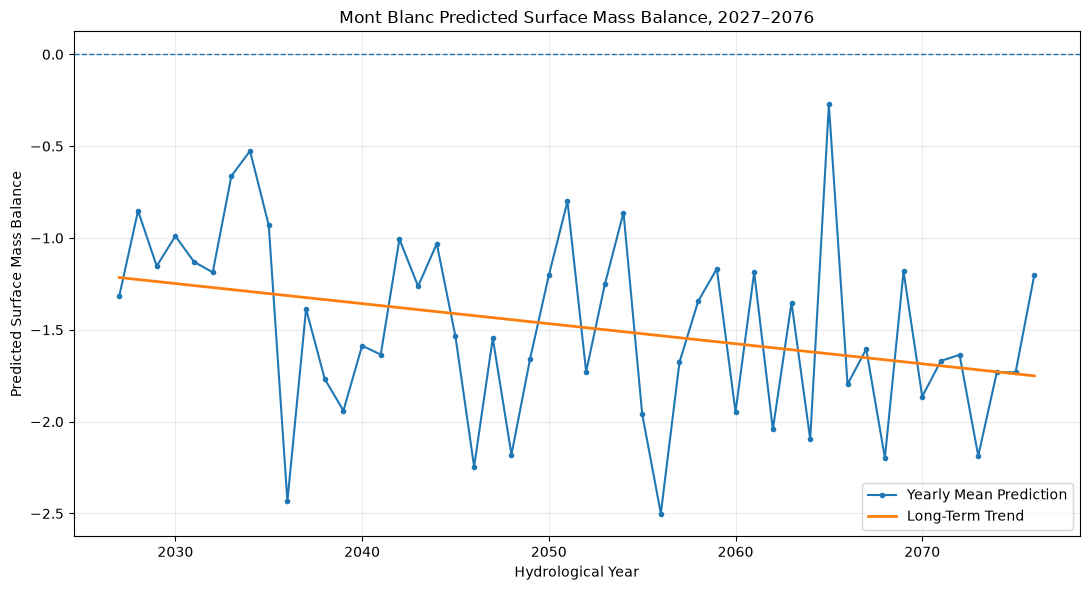

In [18]:
import matplotlib.pyplot as plt

yearly_forecast["trend"] = trend_model.predict(
    yearly_forecast[["hydrological_year"]]
)

plt.figure(figsize=(11, 6))

plt.plot(
    yearly_forecast["hydrological_year"],
    yearly_forecast["mean"],
    marker="o",
    markersize=3,
    label="Yearly Mean Prediction"
)

plt.plot(
    yearly_forecast["hydrological_year"],
    yearly_forecast["trend"],
    linewidth=2,
    label="Long-Term Trend"
)

plt.axhline(0, linewidth=1, linestyle="--")

plt.xlabel("Hydrological Year")
plt.ylabel("Predicted Surface Mass Balance")
plt.title("Mont Blanc Predicted Surface Mass Balance, 2027–2076")

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

### Compare the Beginning and End of the Forecast

To make the long-term change easier to interpret, the average predicted surface mass balance during the first ten forecast years is compared with the final ten forecast years.

Using decade averages reduces the influence of unusually high or low individual years and provides a clearer comparison between the beginning and end of the projection period.

In [19]:
first_decade = yearly_forecast[
    yearly_forecast["hydrological_year"].between(2027, 2036)
]["mean"].mean()

last_decade = yearly_forecast[
    yearly_forecast["hydrological_year"].between(2067, 2076)
]["mean"].mean()

decade_change = last_decade - first_decade

print("First decade (2027-2036) mean:", first_decade)
print("Last decade (2067-2076) mean:", last_decade)
print("Change:", decade_change)

First decade (2027-2036) mean: -1.1177853505267223
Last decade (2067-2076) mean: -1.7003766483067406
Change: -0.5825912977800183


### Forecast Results

The future projections show substantial year to year variation in predicted surface mass balance, but the overall trend becomes more negative from 2027–2076.

The average predicted mass balance for 2027–2036 was approximately -1.12, compared with approximately -1.70 for 2067–2076. This represents a decrease of about 0.58 between the first and final decades of the forecast.

The fitted trend across the full 50-year period also decreased by approximately 0.11 per decade. Together, these results indicate increasingly negative surface mass balance under the SSP2-4.5 climate scenario, although individual years can vary considerably.

These predictions represent glacier-wide surface mass balance and do not directly predict changes in glacier area or geometry.

## Save Future Mass Balance Predictions

The glacier level predictions are saved as a processed dataset so they can be used separately from the modeling notebook. Each row represents one glacier record and one hydrological year, along with its location, future climate features, and predicted surface mass balance.

This file preserves the full model output before any additional processing is performed for the 3D visualization.

In [20]:
prediction_path = (
    PROCESSED_DIR /
    "MontBlanc_Future_MassBalance_Predictions_SSP245_2027-2076.csv"
)

future_predictions.to_csv(prediction_path, index=False)

print("Saved:", prediction_path)
print("Shape:", future_predictions.shape)
print(
    "Years:",
    future_predictions["hydrological_year"].min(),
    "-",
    future_predictions["hydrological_year"].max()
)
print(
    "Glacier records:",
    future_predictions["glacier_index"].nunique()
)
print(
    "Missing predictions:",
    future_predictions["predicted_mass_balance"].isna().sum()
)

Saved: ../data/processed/MontBlanc_Future_MassBalance_Predictions_SSP245_2027-2076.csv
Shape: (2900, 9)
Years: 2027 - 2076
Glacier records: 58
Missing predictions: 0


## Create Yearly Forecast Summary

The full prediction dataset contains separate predictions for each glacier record. A second dataset is created to provide a simpler year by year summary of the Mont Blanc study area.

This summary preserves the mean, minimum, and maximum predicted surface mass balance for each hydrological year. It can be used for graphs, interface information, or later visualization integration without requiring the visualization to process all 58 glacier records.

No glacier area or geometry changes are calculated here because the mass balance model does not directly predict glacier boundaries.

In [21]:
yearly_summary = (
    future_predictions
    .groupby("hydrological_year")["predicted_mass_balance"]
    .agg(
        mean_predicted_mass_balance="mean",
        minimum_predicted_mass_balance="min",
        maximum_predicted_mass_balance="max"
    )
    .reset_index()
)

summary_path = (
    PROCESSED_DIR /
    "MontBlanc_Yearly_MassBalance_Summary_SSP245_2027-2076.csv"
)

yearly_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)
print("Shape:", yearly_summary.shape)
print(
    "Years:",
    yearly_summary["hydrological_year"].min(),
    "-",
    yearly_summary["hydrological_year"].max()
)
print("Missing values:", yearly_summary.isna().sum().sum())

yearly_summary.head()

Saved: ../data/processed/MontBlanc_Yearly_MassBalance_Summary_SSP245_2027-2076.csv
Shape: (50, 4)
Years: 2027 - 2076
Missing values: 0


,hydrological_year,mean_predicted_mass_balance,minimum_predicted_mass_balance,maximum_predicted_mass_balance
0,2027,-1.314095,-1.425734,-1.129674
1,2028,-0.851924,-0.948867,-0.649522
2,2029,-1.153079,-1.218592,-0.980069
3,2030,-0.989741,-1.057447,-0.807198
4,2031,-1.129923,-1.220765,-0.980673


## Prepare Visualization Data

The visualization will represent glacier change across the Mont Blanc study area as a whole rather than showing separate changes for each glacier record.

The 58 glacier level predictions are summarized into one mean predicted surface mass balance value for each year. Keeping the full annual time series allows the visualization to use yearly values or larger time intervals without rerunning the forecasting model.

In [22]:
visualization_data = yearly_summary[
    [
        "hydrological_year",
        "mean_predicted_mass_balance"
    ]
].copy()

visualization_data.columns = [
    "year",
    "predicted_mass_balance"
]

print("Visualization rows:", len(visualization_data))
print(
    "Years:",
    visualization_data["year"].min(),
    "-",
    visualization_data["year"].max()
)
print("Missing values:", visualization_data.isna().sum().sum())

print("\nFirst 5 years:")
print(visualization_data.head().to_string(index=False))

print("\nLast 5 years:")
print(visualization_data.tail().to_string(index=False))

Visualization rows: 50
Years: 2027 - 2076
Missing values: 0

First 5 years:
 year  predicted_mass_balance
 2027               -1.314095
 2028               -0.851924
 2029               -1.153079
 2030               -0.989741
 2031               -1.129923

Last 5 years:
 year  predicted_mass_balance
 2072               -1.636374
 2073               -2.186459
 2074               -1.729714
 2075               -1.731786
 2076               -1.202519


## Export Visualization JSON

The yearly Mont Blanc mass balance predictions are exported as JSON for use by the Three.js visualization.

Each entry contains a year and the mean predicted surface mass balance across the study area. The annual values are preserved so the visualization can later display yearly changes or select larger intervals such as 5-year or 10-year steps.

In [23]:
import json

visualization_path = (
    PROCESSED_DIR /
    "MontBlanc_Visualization_MassBalance_SSP245_2027-2076.json"
)

visualization_records = visualization_data.to_dict(orient="records")

with open(visualization_path, "w") as file:
    json.dump(visualization_records, file, indent=2)

print("Saved:", visualization_path)
print("Years exported:", len(visualization_records))
print("First entry:", visualization_records[0])
print("Last entry:", visualization_records[-1])

Saved: ../data/processed/MontBlanc_Visualization_MassBalance_SSP245_2027-2076.json
Years exported: 50
First entry: {'year': 2027, 'predicted_mass_balance': -1.3140951742539932}
Last entry: {'year': 2076, 'predicted_mass_balance': -1.2025187426716524}


### Verify Visualization Output

The exported JSON file is loaded again to confirm that it contains the expected 50 annual predictions and that the year range and mass balance values were saved correctly.

In [24]:
with open(visualization_path, "r") as file:
    saved_visualization_data = json.load(file)

print("JSON records:", len(saved_visualization_data))
print(
    "Years:",
    saved_visualization_data[0]["year"],
    "-",
    saved_visualization_data[-1]["year"]
)

missing_values = sum(
    record["predicted_mass_balance"] is None
    for record in saved_visualization_data
)

print("Missing mass balance values:", missing_values)
print("\nFirst record:")
print(saved_visualization_data[0])

print("\nLast record:")
print(saved_visualization_data[-1])

JSON records: 50
Years: 2027 - 2076
Missing mass balance values: 0

First record:
{'year': 2027, 'predicted_mass_balance': -1.3140951742539932}

Last record:
{'year': 2076, 'predicted_mass_balance': -1.2025187426716524}


## Forecasting Summary

The final Linear Regression model was retrained using the full historical dataset from 1968–2015 and applied to the bias corrected CNRM-CM6-1 SSP2-4.5 climate projections for 2027–2076.

The model produced 2,900 future surface mass balance predictions covering 58 glacier records over 50 years. The predictions show substantial year-to-year variation, but the overall trend becomes more negative over the forecast period. The average predicted mass balance decreased from approximately -1.12 during 2027–2036 to -1.70 during 2067–2076.

The complete glacier level predictions were saved for future analysis. A yearly summary was also created by averaging the 58 glacier predictions for each year, and these annual values were exported as JSON for use by the 3D visualization.

The forecast represents changes in glacier wide surface mass balance rather than direct predictions of glacier area or geometry. How these values are visually represented on the terrain will be handled separately during visualization integration.